# Label Propagation — λ Sensitivity

Reproduces APORIA-LP sensitivity to the regularisation parameter λ -- Assess the better parameter lambda =1.2 used in the paper (Figure 5).

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)
    
os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose aliases used downstream
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
maxResponsesPerPrompt = cfg.dataset.max_responses_per_prompt


In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [5]:
df = ap.load_dataframe(cfg)


In [6]:
model_order, model_rank = ap.build_model_size_order(cfg)

false_premise = (
    {pid: fp for pid, fp in df[["prompt_id", "false_premise"]].value_counts().keys()}
    if "false_premise" in df.columns
    else None
)


## Experiment

In [7]:
lambda_values = [
    1e-4, 3e-4,
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 2e-1, 3e-1, 5e-1, 7e-1,
    1e+0, 1.4e+0, 2e+0, 3e+0, 5e+0,
    1e+1, 3e+1,
    1e+2, 3e+2,
]

results_lambda = ap.run_full_lambda_sensitivity_study(
    df, cfg,
    lambda_values   = lambda_values,
    test_fraction   = 0.2,
    n_splits        = 5,
    use_cache       = True,
    cache_dir       = f"{cfg.cache.root}/LP-lambda-sensitivity",
    overwrite_cache = False,
    logskip         = True,
)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
results_lambda_fine = ap.run_full_lambda_sensitivity_study(
    df, cfg,
    lambda_values   = np.arange(0.5, 4.5, .1),
    test_fraction   = 0.2,
    n_splits        = 5,
    use_cache       = True,
    cache_dir       = f"{cfg.cache.root}/LP-lambda-sensitivity-fine",
    overwrite_cache = False,
    logskip         = True,
)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

## Lambda Sensitivity plot -- Figure 5

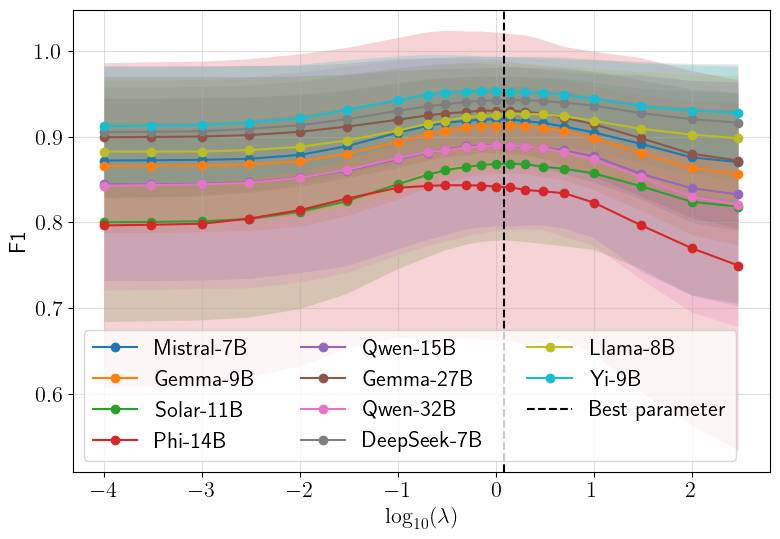

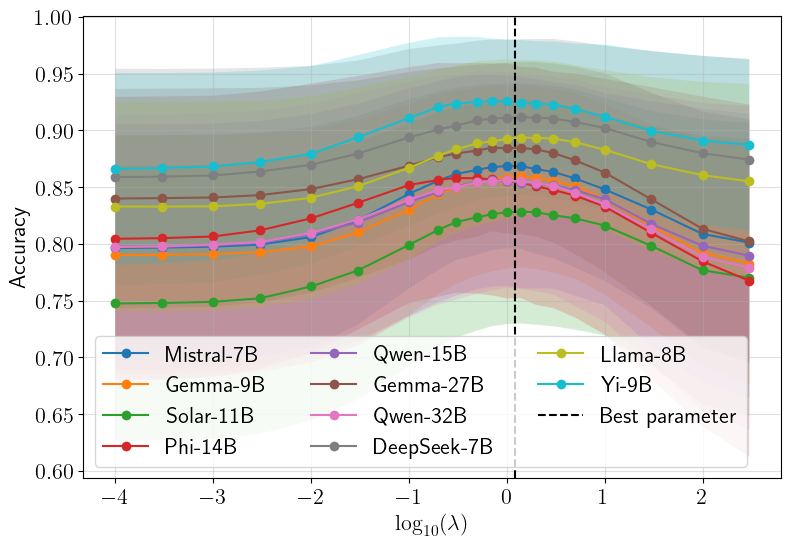

In [9]:
def plot_lambda_sensitivity(
    agg_df,
    model_names,
    metric="f1",
    metric_label='metric',
    ratio=(3, 2),
    scale=3,
    best_reg_lambda=None,
):
    fig, ax = plt.subplots(figsize=[scale * x for x in ratio])

    for mid, name in model_names.items():
        df_m = agg_df[agg_df["model_id"] == mid]
        if df_m.empty:
            continue

        x = np.log10(df_m["lambda_reg"].values)

        ax.plot(
            x,
            df_m[f"{metric_label}_mean"],
            marker="o",
            label=name
        )

        ax.fill_between(
            x,
            df_m[f"{metric_label}_mean"] - df_m[f"{metric_label}_std"],
            df_m[f"{metric_label}_mean"] + df_m[f"{metric_label}_std"],
            alpha=0.2
        )

    if best_reg_lambda is not None:
        ax.axvline(np.log10(best_reg_lambda), ls='--', color='k', label='Best parameter')

    ax.set_xlabel("$\\log_{10}(\\lambda)$", size=16)
    ax.set_ylabel(metric.capitalize(), size=16)
    ax.grid(True, alpha=0.4)

    ax.tick_params(axis='both', labelsize=16)
    ax.legend(ncols=3, fontsize=16)
    # ax.set_title(f"{metric.upper()} vs Fisher regularisation")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

agg_lambda = ap.aggregate_metric_over_lambda(
    results_lambda,
    metric="f1",
    score_metric="accuracy",
    agg_prompts=True,
    agg_models=False
)

fig, ax = plot_lambda_sensitivity(
    agg_lambda,
    model_names=model_names,
    metric="f1",
    best_reg_lambda=best_reg_lambda
)

fig.savefig(f"{figures_dir}/LP_lambda_sensitivity.pdf", bbox_inches='tight')

fig, ax = plot_lambda_sensitivity(
    agg_lambda,
    model_names=model_names,
    metric="accuracy",
    metric_label="score",
    best_reg_lambda=best_reg_lambda
)

fig.savefig(f"{figures_dir}/LP_lambda_sensitivity_acc.pdf", bbox_inches='tight')

In [10]:
agg_lambda_global = ap.aggregate_metric_over_lambda(
    results_lambda,
    metric="f1",
    agg_prompts=True,
    agg_models=True,
)

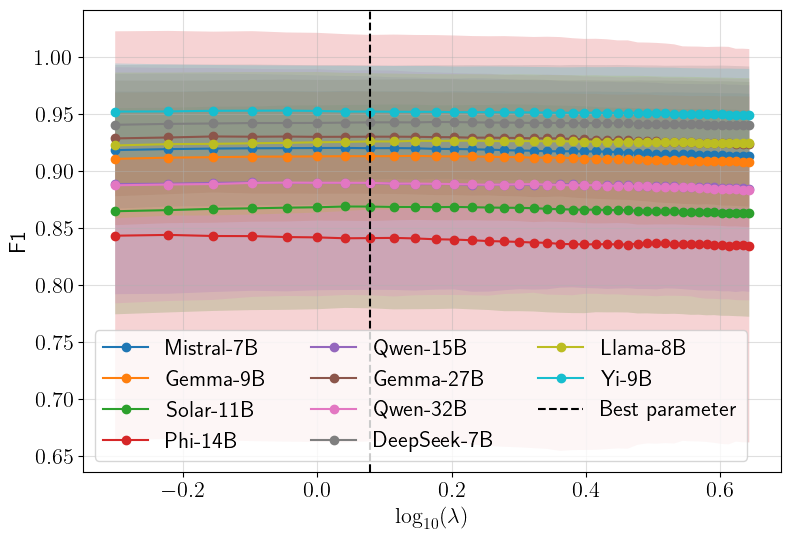

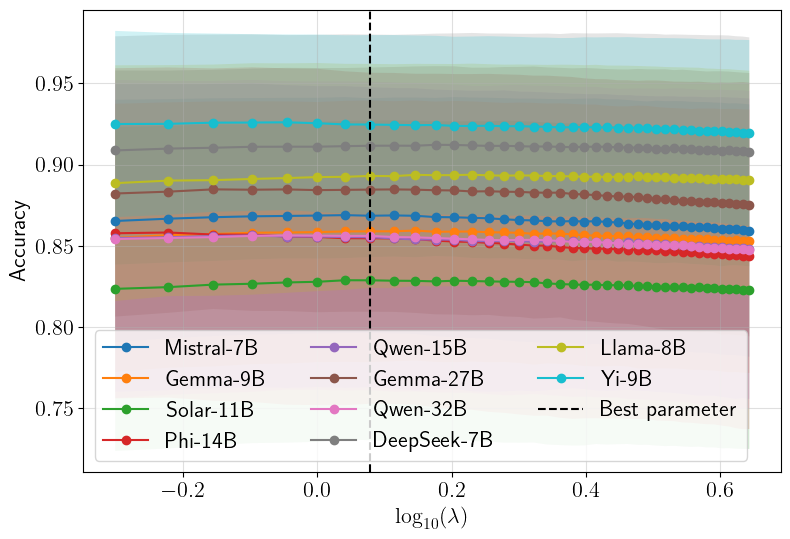

In [11]:
agg_lambda_fine = ap.aggregate_metric_over_lambda(
    results_lambda_fine,
    metric="f1",
    score_metric="accuracy",
    agg_prompts=True,
    agg_models=False,
)
fig, ax = plot_lambda_sensitivity(
    agg_lambda_fine,
    model_names=model_names,
    metric="f1",
    best_reg_lambda=best_reg_lambda,
)
fig, ax = plot_lambda_sensitivity(
    agg_lambda_fine,
    model_names=model_names,
    metric="accuracy",
    metric_label="score",
    best_reg_lambda=best_reg_lambda,
)

## 2D "Constellation" Plot

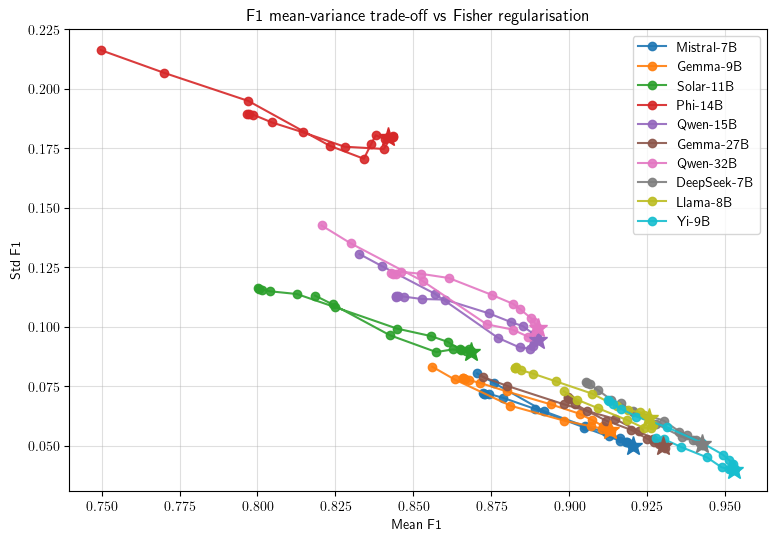

In [12]:
def plot_lambda_sensitivity_2d(
    agg_df,
    model_names,
    metric="f1",
    metric_label="metric",
    ratio=(3, 2),
    scale=3,
    best_reg_lambda=None,
):
    """
    2D sensitivity plot:
      x-axis: metric mean
      y-axis: metric std

    Each model is a trajectory over lambda.
    The best lambda is highlighted with a star (nearest if needed).
    """

    fig, ax = plt.subplots(figsize=[scale * x for x in ratio])

    for mid, name in model_names.items():
        df_m = agg_df[agg_df["model_id"] == mid]
        if df_m.empty:
            continue

        # ---- sort by lambda (important for line continuity)
        df_m = df_m.sort_values("lambda_reg")

        x = df_m[f"{metric_label}_mean"].values
        y = df_m[f"{metric_label}_std"].values

        ax.plot(
            x,
            y,
            marker="o",
            label=name,
            alpha=0.9
        )

        # ---- highlight best lambda (nearest if not exact)
        if best_reg_lambda is not None:
            idx = np.argmin(np.abs(df_m["lambda_reg"].values - best_reg_lambda))

            ax.plot(
                x[idx],
                y[idx],
                marker="*",
                markersize=14,
                color=ax.lines[-1].get_color(),
                zorder=5
            )

    ax.set_xlabel(f"Mean {metric.upper()}")
    ax.set_ylabel(f"Std {metric.upper()}")
    ax.grid(True, alpha=0.4)
    ax.legend()
    ax.set_title(f"{metric.upper()} mean-variance trade-off vs Fisher regularisation")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

fig, ax = plot_lambda_sensitivity_2d(
    agg_df=agg_lambda,
    model_names=model_names,
    metric="f1",
    metric_label="metric",
    best_reg_lambda=best_reg_lambda,
    scale=3
)

## Choose a single λ that minimises the average relative regret with respect to the best achievable λ for each (model, prompt) task.

Let:
 - $s_{m,p}(\lambda)$ be the score (e.g. F1) for model $m$, prompt $p$, and regularisation $\lambda$
 - $s^*_{m,p} = \max_{\lambda} s_{m,p}(\lambda)$

Define the relative loss (regret):
$$
    \ell_{m,p}(\lambda)
    \;=\;
    \frac{s^*_{m,p} - s_{m,p}(\lambda)}{s^*_{m,p}}
$$

Then define the average relative loss:
$$
    L(\lambda) \;=\; \mathbb{E}_{m,p}[\ell_{m,p}(\lambda)]
$$

Your chosen $\lambda$ is:
$$
    \lambda^\star = \arg\min_{\lambda} L(\lambda)
$$

In [13]:
# ===== ===== ===== ===== ===== ===== ===== =====

df_agg = ap.aggregate_over_runs(results_lambda_fine, metric="accuracy")
df_best = ap.compute_best_scores(df_agg, metric="accuracy")
df_rel  = ap.compute_relative_loss(df_agg, df_best, metric="accuracy")
df_loss = ap.aggregate_relative_loss(df_rel)

lambda_star = ap.select_lambda_min_regret(df_loss)

print("lambda_star (acc)", lambda_star, '\n')

df_agg = ap.aggregate_over_runs(results_lambda_fine, metric="f1")
df_best = ap.compute_best_scores(df_agg, metric="f1")
df_rel  = ap.compute_relative_loss(df_agg, df_best, metric="f1")
df_loss = ap.aggregate_relative_loss(df_rel)

lambda_star = ap.select_lambda_min_regret(df_loss)

print("lambda_star (f1)", lambda_star, '\n')

lambda_star_worst = (
    df_loss
    .sort_values("rel_loss_max")
    .iloc[0]
)

print("lambda_star_worst", lambda_star_worst)

lambda_star (acc) lambda_reg       1.200000
rel_loss_mean    0.013038
rel_loss_std     0.013338
rel_loss_max     0.107527
Name: 7, dtype: float64 

lambda_star (f1) lambda_reg       1.200000
rel_loss_mean    0.010495
rel_loss_std     0.029964
rel_loss_max     1.000000
Name: 7, dtype: float64 

lambda_star_worst lambda_reg       4.200000
rel_loss_mean    0.014897
rel_loss_std     0.018345
rel_loss_max     0.283879
Name: 37, dtype: float64


In [14]:
# ===== ===== ===== ===== ===== ===== ===== =====

avg_best = ap.compute_average_best_lambda(df_agg)

print("Min-regret lambda:", lambda_star["lambda_reg"])
print("Average best lambda:", avg_best)

Min-regret lambda: 1.1999999999999997
Average best lambda: {'mean_best_lambda': np.float64(1.746332046332046), 'median_best_lambda': np.float64(1.2999999999999998)}


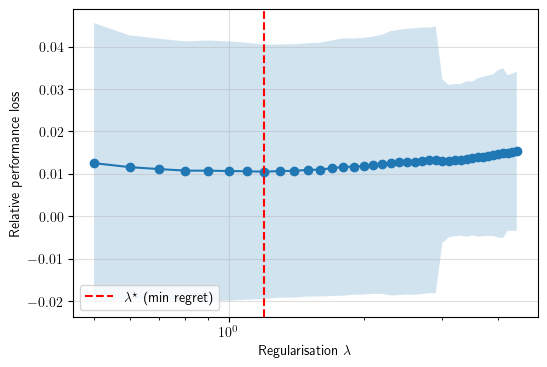

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    df_loss["lambda_reg"],
    df_loss["rel_loss_mean"],
    marker="o"
)

ax.fill_between(
    df_loss["lambda_reg"],
    df_loss["rel_loss_mean"] - df_loss["rel_loss_std"],
    df_loss["rel_loss_mean"] + df_loss["rel_loss_std"],
    alpha=0.2
)

ax.axvline(
    lambda_star["lambda_reg"],
    color="red",
    linestyle="--",
    label=r"$\lambda^\star$ (min regret)"
)

ax.set_xscale("log")
ax.set_xlabel(r"Regularisation $\lambda$")
ax.set_ylabel("Relative performance loss")
ax.grid(True, alpha=0.4)
ax.legend()